# Bankruptcy Prediction — Exploratory Data Analysis

Predict whether a Taiwanese company went bankrupt using 95 financial ratios from the Taiwan Economic Journal (1999-2009). 6,819 firms with a strongly imbalanced target (~3.2% bankrupt).

**Target:** `Bankrupt` (0 = Healthy, 1 = Bankrupt)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/bankruptcy.csv')
if df['Bankrupt'].dtype == object:
    df['Bankrupt'] = (df['Bankrupt'].astype(str).str.lower() == 'yes').astype(int)
print('Shape:', df.shape)
df.head()

Shape: (6819, 95)


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,Continuous_Interest_Rate_After_Tax,Operating_Expense_Rate,R&D_Expense_Rate,Cash_Flow_Rate,InterestBearing_Debt_Interest_Rate,Tax_Rate_A,Net_Value_Per_Share_B,Net_Value_Per_Share_A,Net_Value_Per_Share_C,Persistent_EPS_Last_4_Seasons,Cash_Flow_Per_Share,Revenue_Per_Share,Operating_Profit_Per_Share,Net_Profit_Before_Tax_Per_Share,Realized_Sales_Gross_Profit_Growth_Rate,Operating_Profit_Growth_Rate,AfterTax_Net_Profit_Growth_Rate,Regular_Net_Profit_Growth_Rate,Continuous_Net_Profit_Growth_Rate,Total_Asset_Growth_Rate,Net_Value_Growth_Rate,Total_Asset_Return_Growth_Rate,Cash_Reinvestment_Percent,Current_Ratio,Quick_Ratio,Interest_Expense_Ratio,Total_Debt_to_Net_Worth,Debt_Ratio_Percent,Net_Worth_to_Assets,LongTerm_Fund_Suitability_Ratio_A,Borrowing_Dependency,Contingent_Liabilities_to_Net_Worth,Operating_Profit_to_PaidIn_Capital,Net_Profit_Before_Tax_to_PaidIn_Capital,Inventory_Accounts_Receivable_to_Net_Value,Total_Asset_Turnover,Accounts_Receivable_Turnover,Average_Collection_Days,Inventory_Turnover_Rate,Fixed_Assets_Turnover_Frequency,Net_Worth_Turnover_Rate,Revenue_Per_Person,Operating_Profit_Per_Person,Allocation_Rate_Per_Person,Working_Capital_to_Total_Assets,Quick_Assets_to_Total_Assets,Current_Assets_to_Total_Assets,Cash_to_Total_Assets,Quick_Assets_to_Current_Liability,Cash_to_Current_Liability,Current_Liability_to_Assets,Operating_Funds_to_Liability,Inventory_to_Working_Capital,Inventory_to_Current_Liability,Current_Liabilities_to_Liability,Working_Capital_to_Equity,Current_Liabilities_to_Equity,LongTerm_Liability_to_Current_Assets,Retained_Earnings_to_Total_Assets,Total_Income_to_Total_Expense,Total_Expense_to_Assets,Current_Asset_Turnover_Rate,Quick_Asset_Turnover_Rate,Working_Capital_Turnover_Rate,Cash_Turnover_Rate,Cash_Flow_to_Sales,Fixed_Assets_to_Assets,Current_Liability_to_Liability,Current_Liability_to_Equity,Equity_to_LongTerm_Liability,Cash_Flow_to_Total_Assets,Cash_Flow_to_Liability,CFO_to_Assets,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Liability_Assets_Flag,Net_Income_to_Total_Assets,Total_Assets_to_GNP_Price,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability
0,0,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,0.781929,2.592570e-04,2.884653e-04,0.477800,0.000602,0.001518,0.216341,0.216341,0.216341,0.258013,0.332178,0.026846,0.129143,0.205694,0.022095,0.848031,0.689420,0.689420,0.217595,8.550000e+09,0.000558,0.264055,0.380910,0.014799,0.013536,0.630630,0.001675,0.045681,0.954319,0.006615,0.369637,0.005366,0.128096,0.203544,0.396278,0.115442,0.001049,0.006032,2.520253e-04,0.000401,0.024516,0.026221,0.415628,0.007991,0.814134,0.379162,0.389149,0.214547,0.013949,0.022700,0.049786,0.389006,0.277031,0.002548,0.980840,0.735034,0.327735,0.000000e+00,0.953847,0.002552,0.031021,1.458139e-04,1.477731e-04,0.593979,2.261115e-04,0.671535,0.126175,0.980840,0.327735,0.110933,0.596608,0.435000,0.640667,0.309438,0.019815,0,0.854406,0.007801,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956
1,0,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,0.781588,1.194525e-04,5.600000e+09,0.459113,0.000819,0.082397,0.173149,0.173149,0.173149,0.219911,0.312230,0.052589,0.101376,0.174588,0.022419,0.848212,0.689860,0.689860,0.217646,7.150000e+09,0.000459,0.264625,0.365057,0.009129,0.005370,0.631718,0.008838,0.145539,0.854461,0.005988,0.372533,0.005366,0.101340,0.173652,0.410604,0.241379,0.000903,0.007003,1.110134e-04,0.001036,0.059677,0.024908,0.394021,0.003047,0.819905,0.472840,0.742088,0.083393,0.005628,0.002915,0.151688,0.333883,0.277546,0.009394,0.991961,0.737549,0.334045,3.490

## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (6819, 95)

Dtypes:
float64    93
int64       2
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,mean,std,min,25%,50%,75%,max
Bankrupt,6819.0,3.226280e-02,1.767102e-01,0.0,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
ROA_C_Before_Interest_Depreciation,6819.0,5.051796e-01,6.068564e-02,0.0,0.476527,5.027056e-01,5.355628e-01,1.000000e+00
ROA_A_Before_Interest_After_Tax,6819.0,5.586249e-01,6.562003e-02,0.0,0.535543,5.598016e-01,5.891572e-01,1.000000e+00
ROA_B_Before_Interest_Depreciation_After_Tax,6819.0,5.535887e-01,6.159481e-02,0.0,0.527277,5.522780e-01,5.841051e-01,1.000000e+00
Operating_Gross_Margin,6819.0,6.079480e-01,1.693381e-02,0.0,0.600445,6.059975e-01,6.139142e-01,1.000000e+00
Realized_Sales_Gross_Margin,6819.0,6.079295e-01,1.691607e-02,0.0,0.600434,6.059759e-01,6.138421e-01,1.000000e+00
Operating_Profit_Rate,6819.0,9.987551e-01,1.301003e-02,0.0,0.998969,9.990222e-01,9.990945e-01,1.000000e+00
PreTax_Net_Interest_Rate,6819.0,7.971898e-01,1.286899e-02,0.0,0.797386,7.974636e-01,7.975788e-01,1.000000e+00
AfterTax_Net_Interest_Rate,6819.0,8.090836e-01,1.360065e-02,0.0,0.809312,8.093752e-01,8.094693e-01,1.000000e+00
NonIndustry_Income_Expenditure_Revenue,6819.0,3.036229e-01,1.116344e-02,0.0,0.303466,3.035255e-01,3.035852e-01,1.000000e+00


In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicate rows: 0
Memory (MB): 4.94


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No explicit NaN values')

No explicit NaN values


## 4. Target Variable Distribution

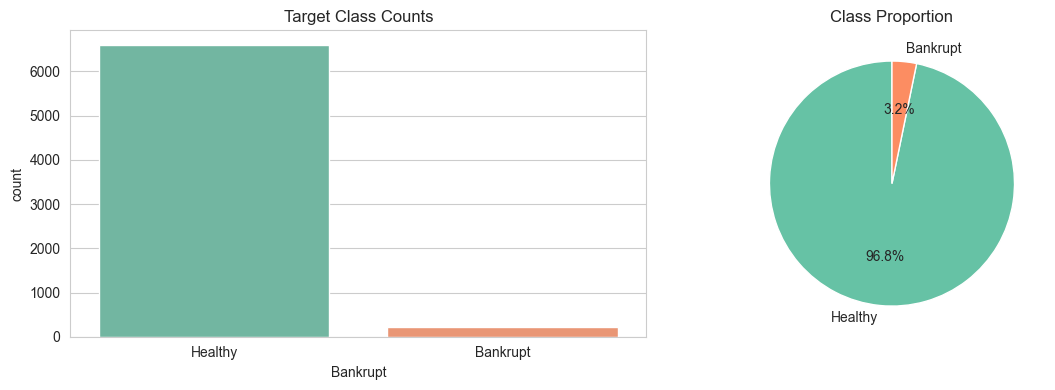


Class balance (%):
Bankrupt
0    96.77
1     3.23
Name: count, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['Bankrupt'].value_counts().sort_index()
sns.countplot(x='Bankrupt', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Counts')
axes[0].set_xticklabels(['Healthy', 'Bankrupt'])
axes[1].pie(target_counts, labels=['Healthy', 'Bankrupt'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()
print('\nClass balance (%):')
print((target_counts / target_counts.sum() * 100).round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Bankrupt' in numeric_cols:
    numeric_cols.remove('Bankrupt')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols)

Numeric features (94):
['ROA_C_Before_Interest_Depreciation', 'ROA_A_Before_Interest_After_Tax', 'ROA_B_Before_Interest_Depreciation_After_Tax', 'Operating_Gross_Margin', 'Realized_Sales_Gross_Margin', 'Operating_Profit_Rate', 'PreTax_Net_Interest_Rate', 'AfterTax_Net_Interest_Rate', 'NonIndustry_Income_Expenditure_Revenue', 'Continuous_Interest_Rate_After_Tax', 'Operating_Expense_Rate', 'R&D_Expense_Rate', 'Cash_Flow_Rate', 'InterestBearing_Debt_Interest_Rate', 'Tax_Rate_A', 'Net_Value_Per_Share_B', 'Net_Value_Per_Share_A', 'Net_Value_Per_Share_C', 'Persistent_EPS_Last_4_Seasons', 'Cash_Flow_Per_Share', 'Revenue_Per_Share', 'Operating_Profit_Per_Share', 'Net_Profit_Before_Tax_Per_Share', 'Realized_Sales_Gross_Profit_Growth_Rate', 'Operating_Profit_Growth_Rate', 'AfterTax_Net_Profit_Growth_Rate', 'Regular_Net_Profit_Growth_Rate', 'Continuous_Net_Profit_Growth_Rate', 'Total_Asset_Growth_Rate', 'Net_Value_Growth_Rate', 'Total_Asset_Return_Growth_Rate', 'Cash_Reinvestment_Percent', 'Curre

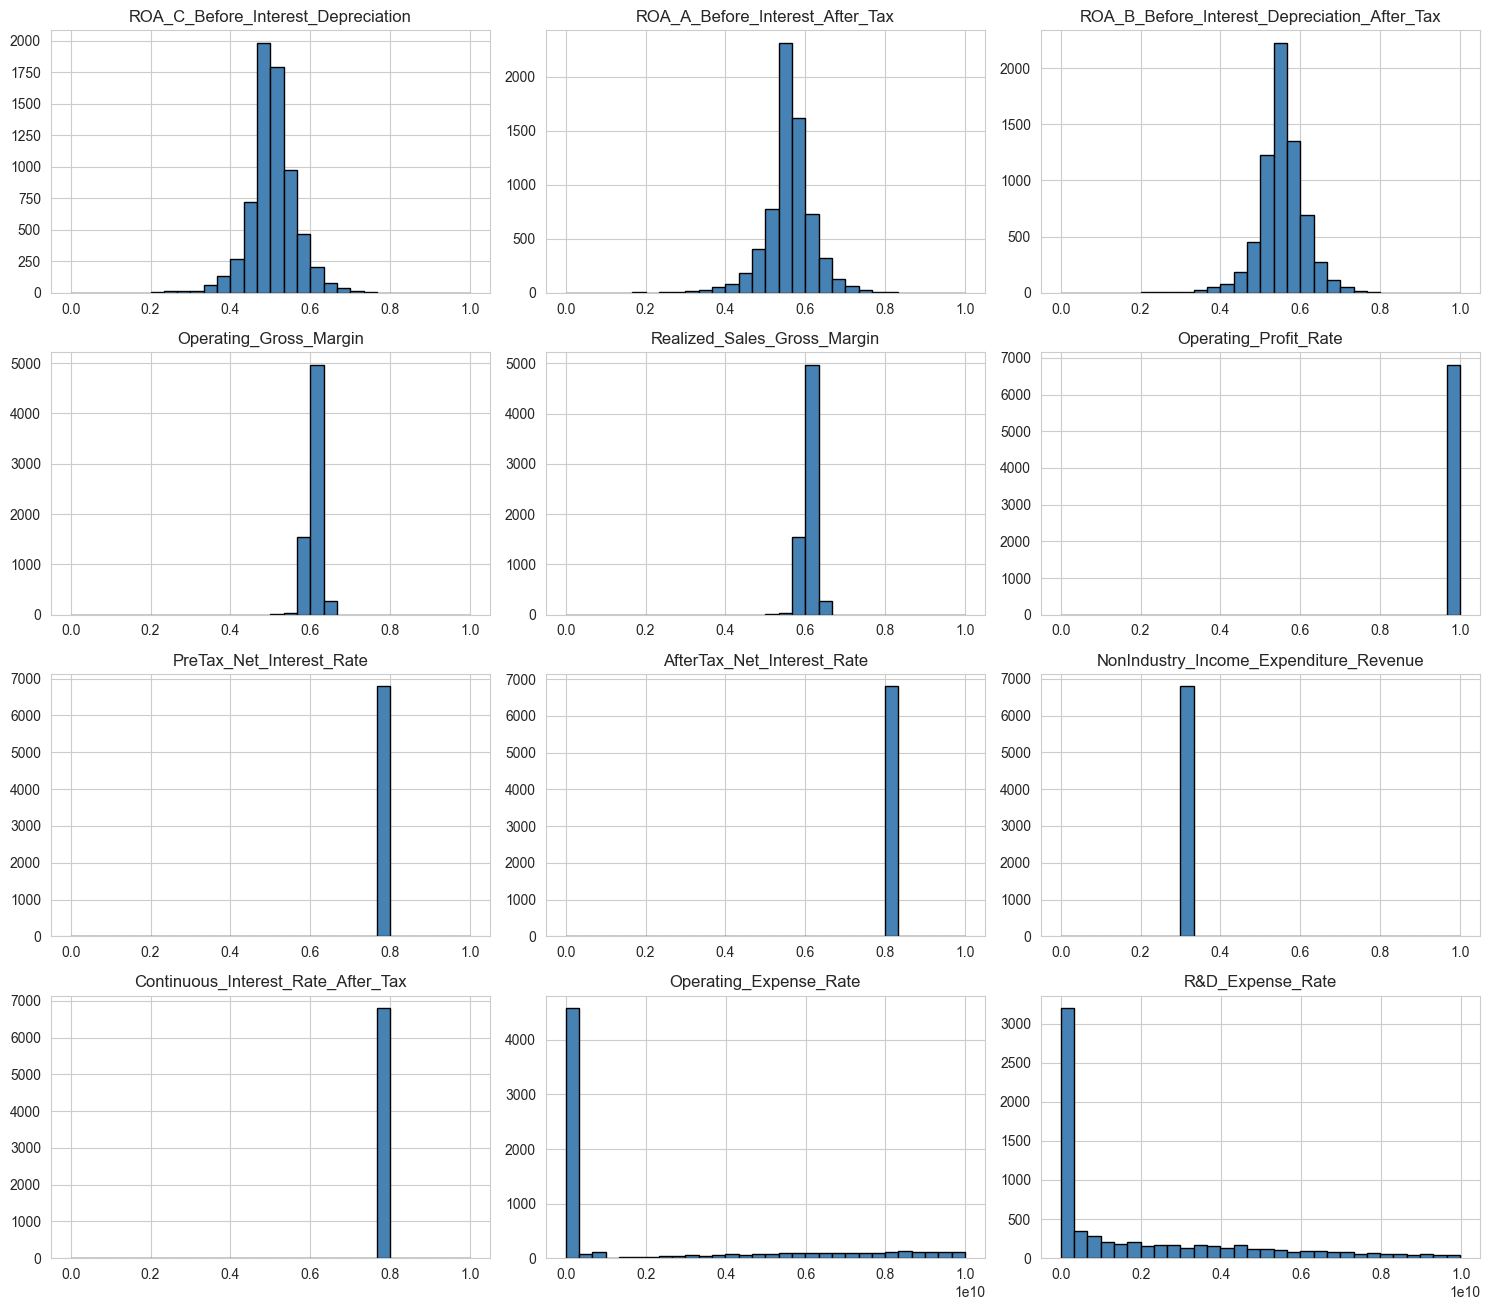

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

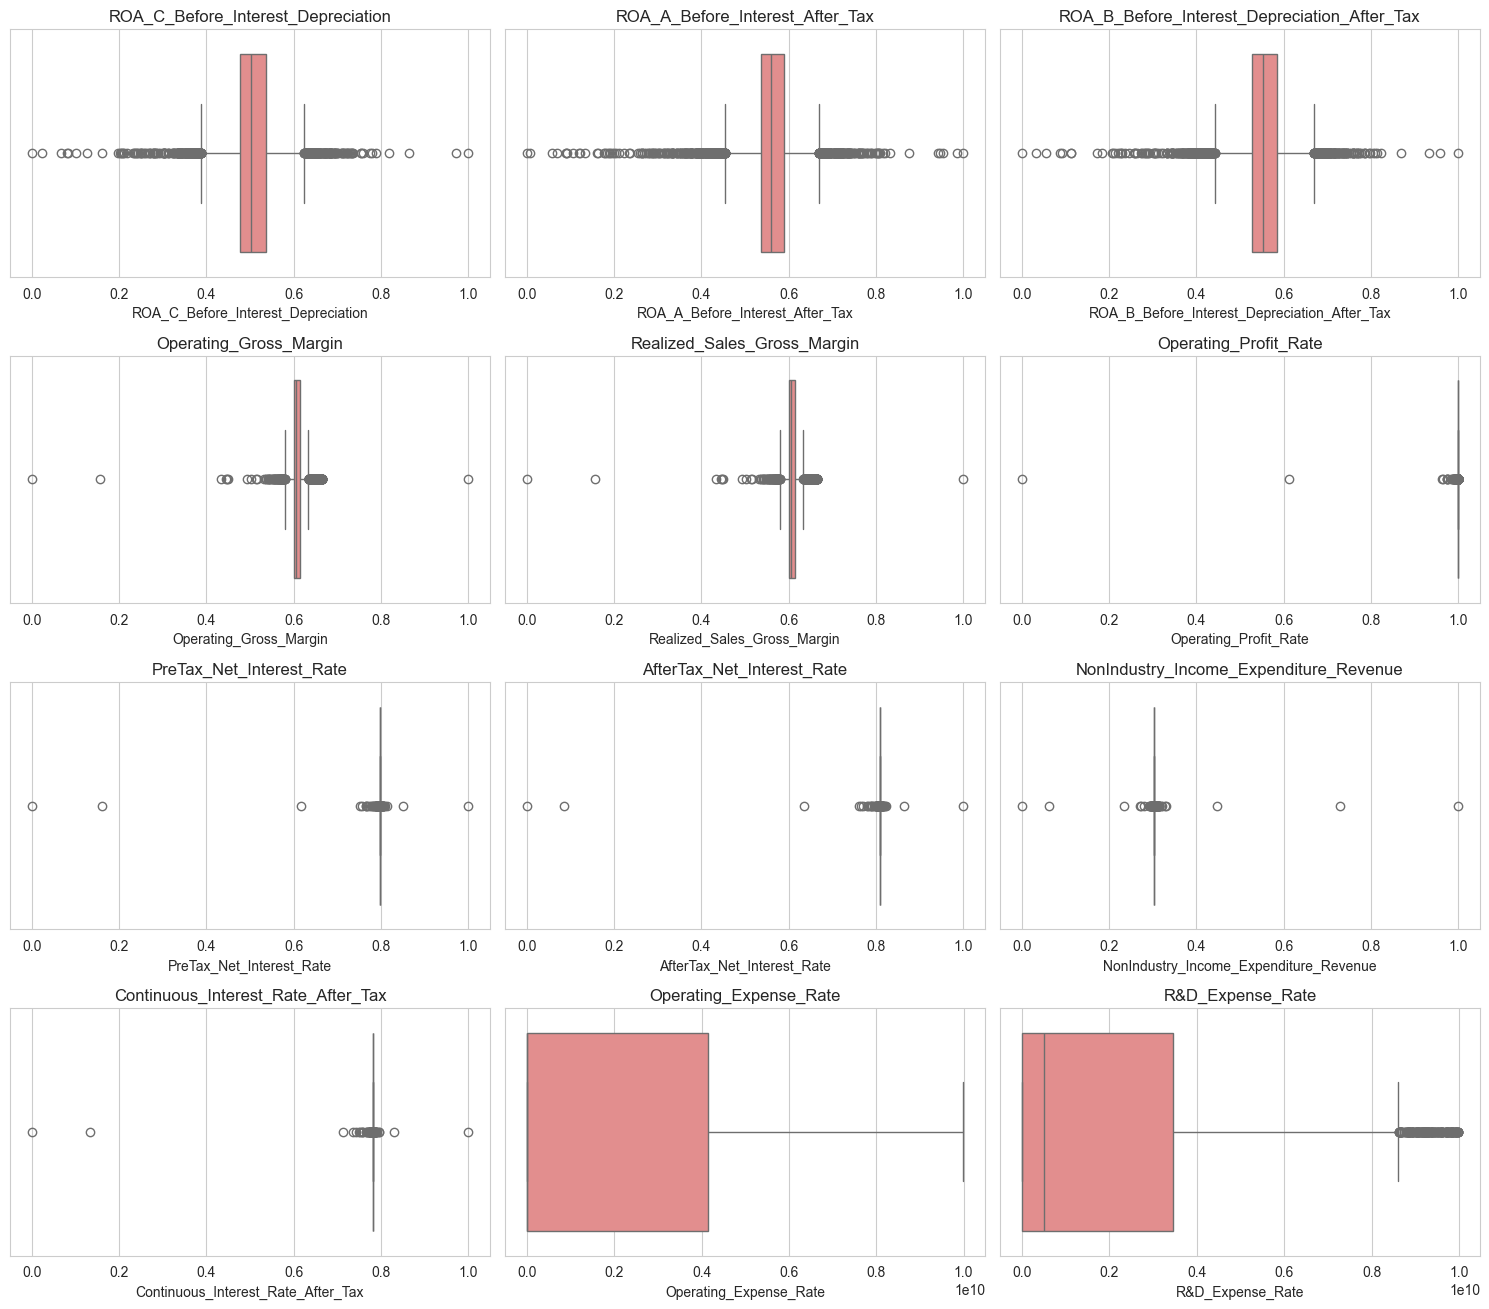

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [11]:
corrs_all = df[numeric_cols + ['Bankrupt']].corr()['Bankrupt'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'Bankrupt'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
Net_Income_to_Total_Assets                      0.315
ROA_A_Before_Interest_After_Tax                 0.283
ROA_B_Before_Interest_Depreciation_After_Tax    0.273
ROA_C_Before_Interest_Depreciation              0.261
Debt_Ratio_Percent                              0.250
Net_Worth_to_Assets                             0.250
Name: Bankrupt, dtype: float64


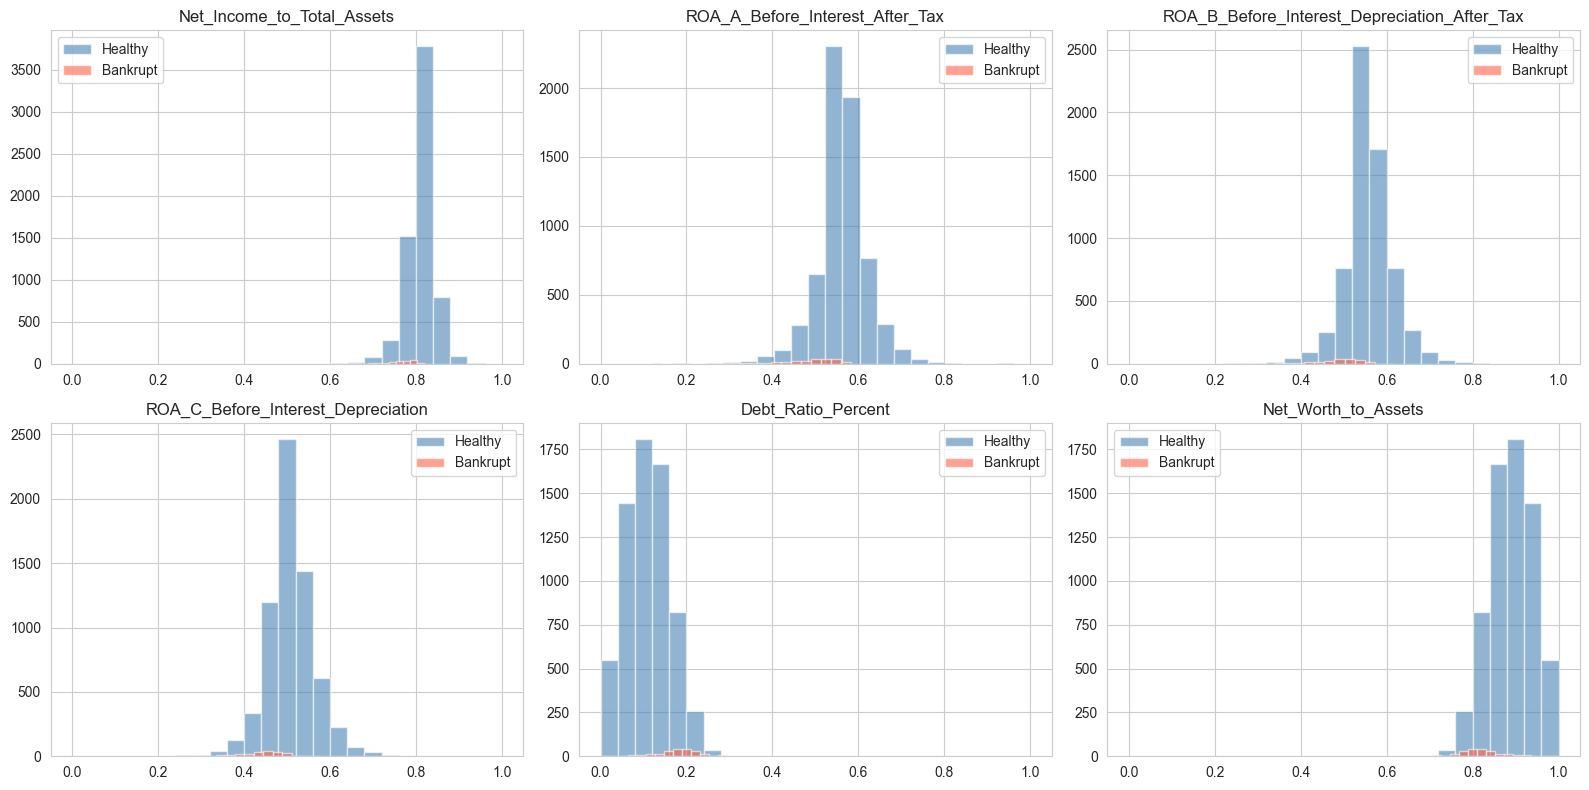

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['Healthy', 'Bankrupt']
colors = ['steelblue', 'tomato']
for i, col in enumerate(top_features[:6]):
    for cls, lbl, c in [(0, labels[0], colors[0]), (1, labels[1], colors[1])]:
        axes[i].hist(df[df['Bankrupt']==cls][col].dropna(), bins=25, alpha=0.6, label=lbl, color=c)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [13]:
means = df.groupby('Bankrupt')[numeric_cols].mean().T
means.columns = ['Healthy', 'Bankrupt']
means['Difference'] = means.iloc[:, 1] - means.iloc[:, 0]
means.sort_values('Difference', key=abs, ascending=False).round(3).head(15)

,Healthy,Bankrupt,Difference
Fixed_Assets_Turnover_Frequency,9.756574e+08,1.996603e+09,1.020945e+09
Total_Asset_Growth_Rate,5.531603e+09,4.803017e+09,-7.285860e+08
Quick_Asset_Turnover_Rate,2.147829e+09,2.640836e+09,4.930069e+08
R&D_Expense_Rate,1.961923e+09,1.605623e+09,-3.562993e+08
Cash_Turnover_Rate,2.481653e+09,2.181733e+09,-2.999205e+08
Cash_to_Current_Liability,2.989953e+07,2.549409e+08,2.250414e+08
Current_Asset_Turnover_Rate,1.189712e+09,1.380154e+09,1.904424e+08
Operating_Expense_Rate,1.998943e+09,1.887486e+09,-1.114569e+08
Total_Assets_to_GNP_Price,1.621670e+07,9.100000e+07,7.478330e+07
Net_Value_Growth_Rate,2.045765e+05,4.240909e+07,4.220451e+07


## 7. Correlation Analysis

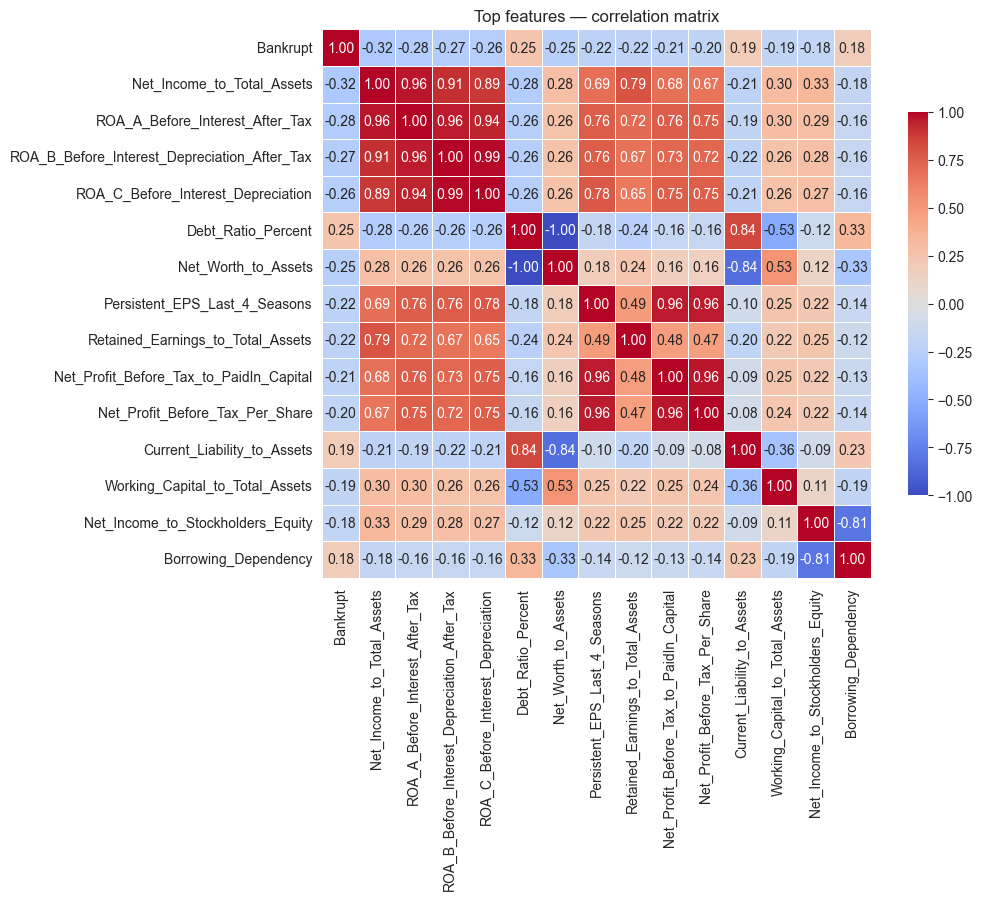

In [14]:
# Restrict to top numeric features for legibility
top_numeric = corrs_all.head(15).index.tolist()
if 'Bankrupt' not in top_numeric:
    top_numeric.append('Bankrupt')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

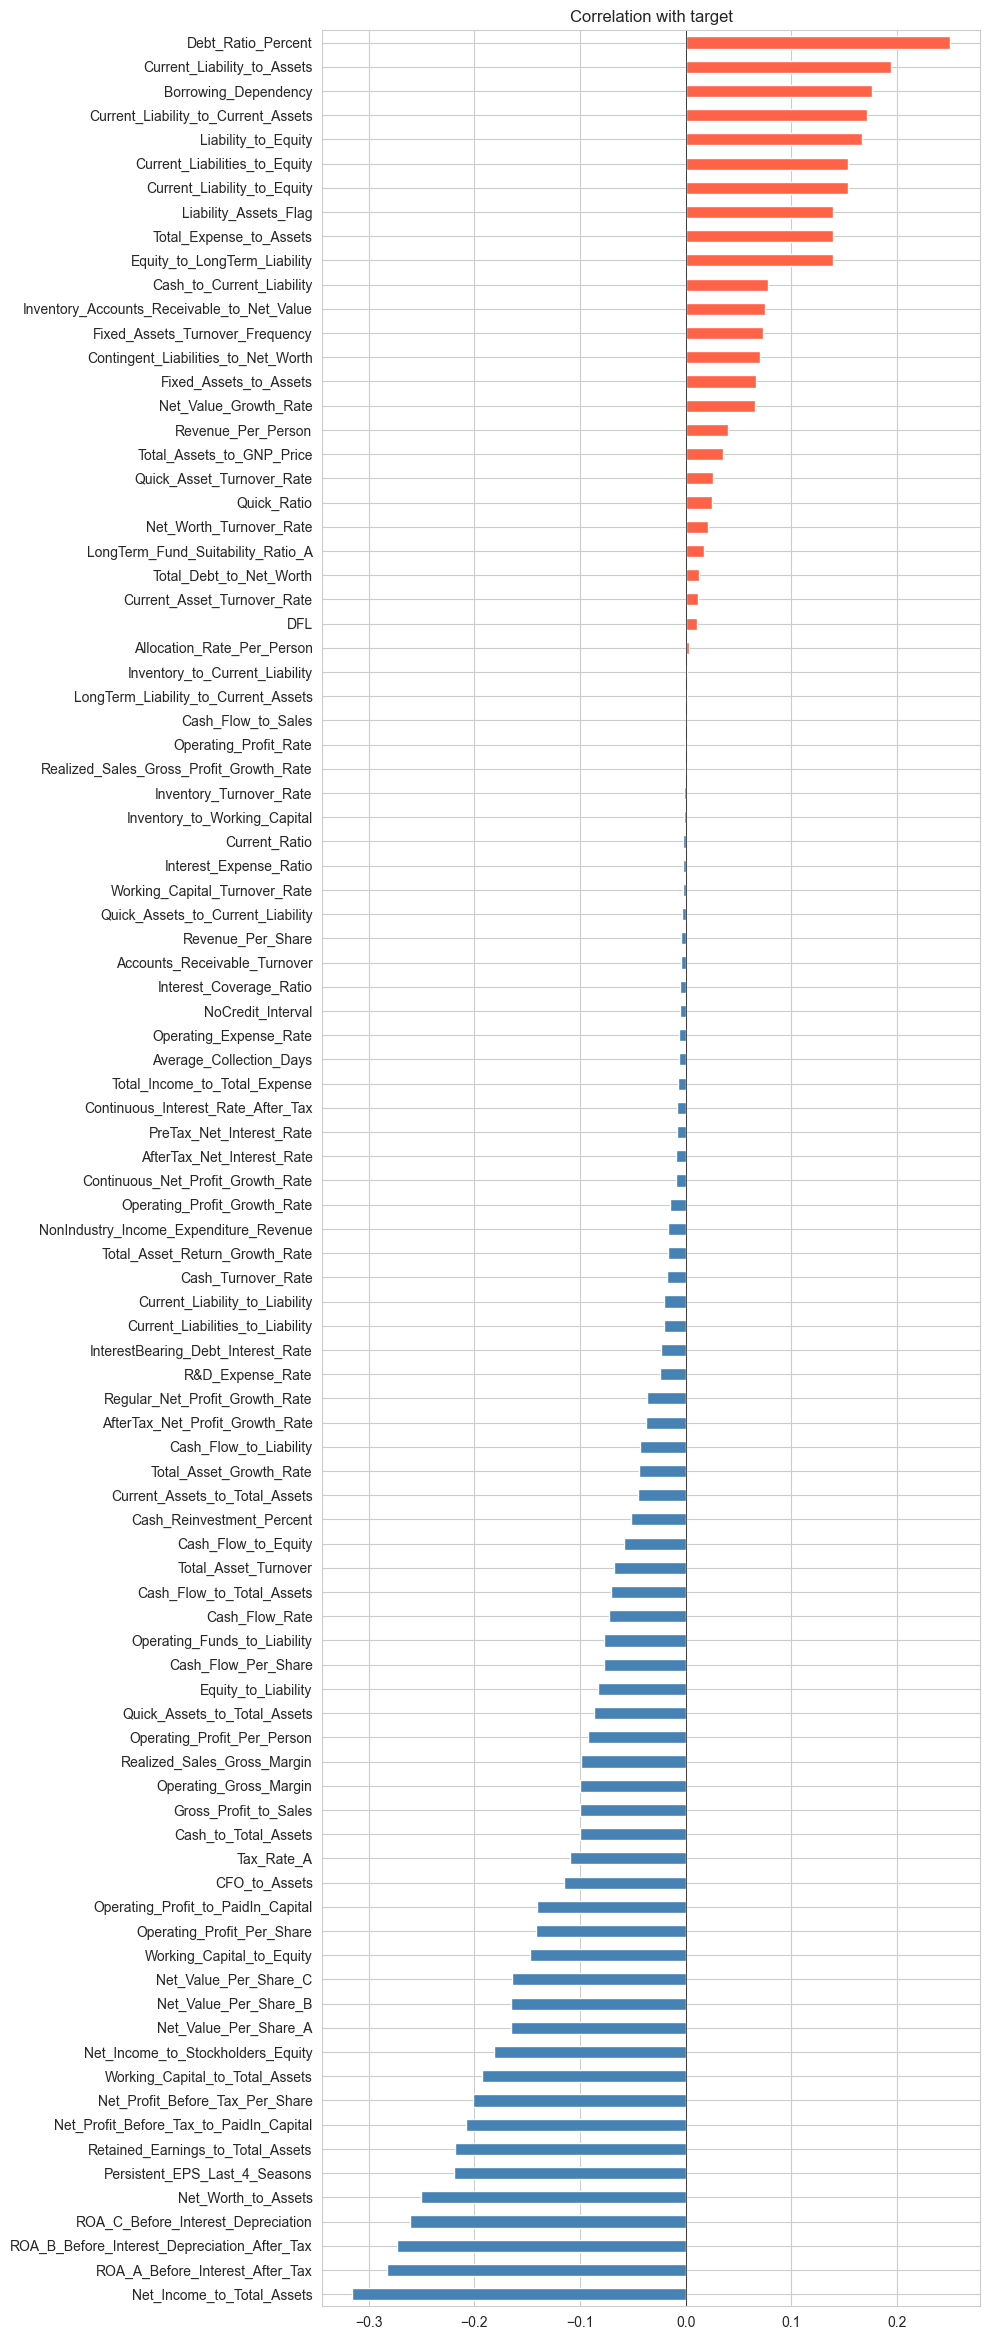

In [15]:
target_corr = df[numeric_cols + ['Bankrupt']].corr()['Bankrupt'].drop('Bankrupt').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Profitability, Leverage, Liquidity

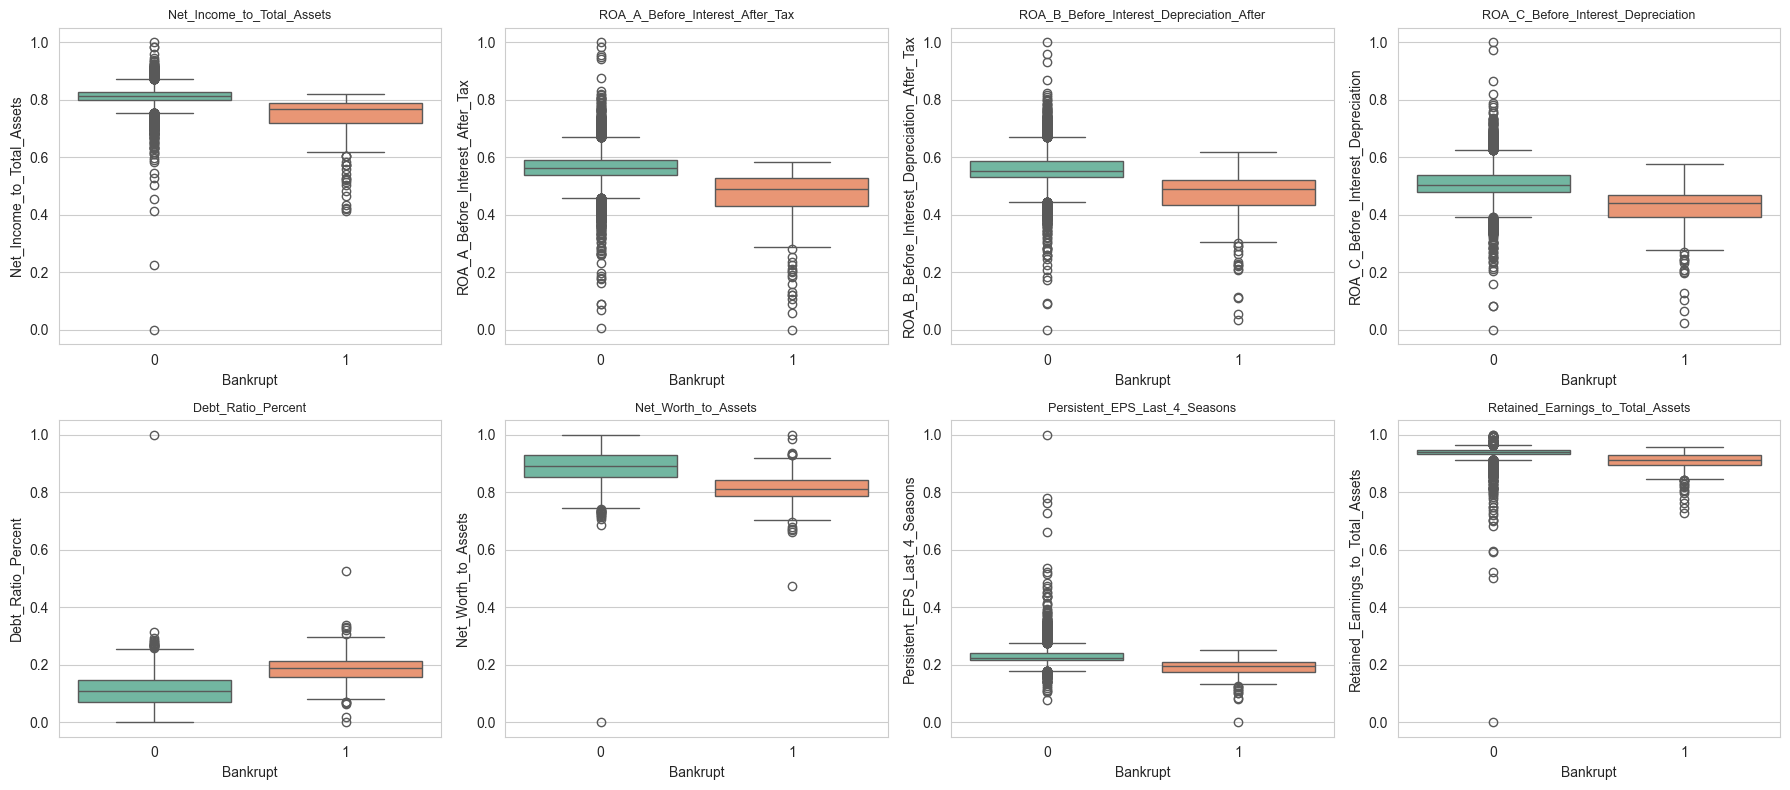

In [16]:
# Top 8 features most correlated with bankruptcy
corrs = df.corr()['Bankrupt'].drop('Bankrupt').sort_values(key=abs, ascending=False).head(8)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(corrs.index):
    sns.boxplot(x='Bankrupt', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col[:40], fontsize=9)
plt.tight_layout(); plt.show()

In [17]:
# Class imbalance summary
n_total = len(df); n_bk = df['Bankrupt'].sum()
print(f'Healthy : {n_total - n_bk:>5} ({(n_total - n_bk)/n_total:.2%})')
print(f'Bankrupt: {n_bk:>5} ({n_bk/n_total:.2%})')
print(f'Imbalance ratio (healthy:bankrupt): {(n_total - n_bk) / n_bk:.1f}:1')

Healthy :  6599 (96.77%)
Bankrupt:   220 (3.23%)
Imbalance ratio (healthy:bankrupt): 30.0:1


## 9. Pair Plot of Top Features

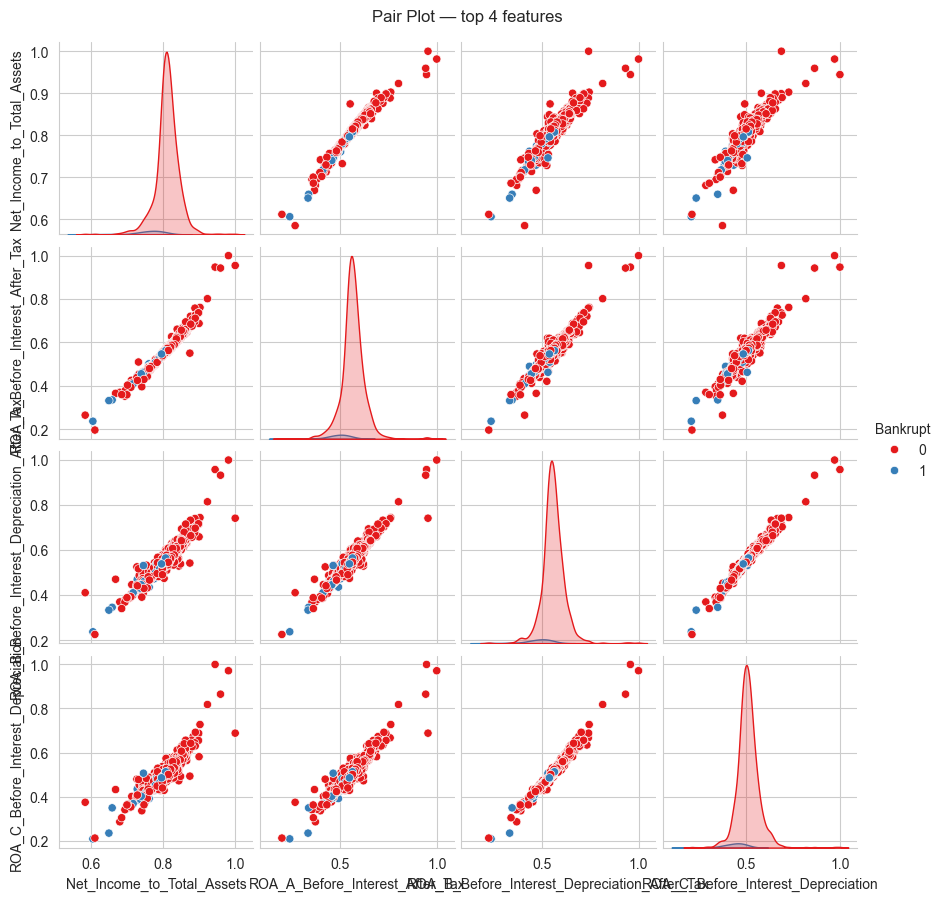

In [18]:
sample = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['Bankrupt']].dropna(),
             hue='Bankrupt', palette='Set1', diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [19]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Class 0 count', 'Class 1 count',
               'Class imbalance ratio', 'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df),
        df.shape[1] - 1,
        int((df['Bankrupt'] == 0).sum()),
        int((df['Bankrupt'] == 1).sum()),
        f"{(df['Bankrupt'] == 0).sum() / max(1, (df['Bankrupt'] == 1).sum()):.2f}:1",
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,6819
1,Total features,94
2,Class 0 count,6599
3,Class 1 count,220
4,Class imbalance ratio,30.00:1
5,Top correlated feature,Net_Income_to_Total_Assets
6,Top correlation value,0.315
